<img src=../figures/Brown_logo.svg width=50%>

## Data-Driven Design & Analyses of Structures & Materials (3dasm)

## Lecture 17

### Martin van der Schelling | <a href = "mailto: m.p.vanderschelling@tudelft.nl">m.p.vanderschelling@tudelft.nl</a>  | Doctoral Candidate

### Miguel A. Bessa | <a href = "mailto: miguel_bessa@brown.edu">miguel_bessa@brown.edu</a>  | Associate Professor

**What:** A lecture of the "3dasm" course

**Where:** This notebook comes from this [repository](https://github.com/bessagroup/3dasm_course)

**Reference for entire course:** Murphy, Kevin P. *Probabilistic machine learning: an introduction*. MIT press, 2022. Available online [here](https://probml.github.io/pml-book/book1.html)

**How:** We try to follow Murphy's book closely, but the sequence of Chapters and Sections is different. The intention is to use notebooks as an introduction to the topic and Murphy's book as a resource.
* If working offline: Go through this notebook and read the book.
* If attending class in person: listen to me (!) but also go through the notebook in your laptop at the same time. Read the book.
* If attending lectures remotely: listen to me (!) via Zoom and (ideally) use two screens where you have the notebook open in 1 screen and you see the lectures on the other. Read the book.

## **OPTION 1**. Run this notebook **locally in your computer**:
1. Confirm that you have the '3dasm' mamba (or conda) environment (see Lecture 1).
2. Go to the 3dasm_course folder in your computer and pull the last updates of the [repository](https://github.com/bessagroup/3dasm_course):
```
git pull
```
    - Note: if you can't pull the repo due to conflicts (and you can't handle these conflicts), use this command (with **caution**!) and your repo becomes the same as the one online:
```
git reset --hard origin/main
```
3. Open command window and load jupyter notebook (it will open in your internet browser):
```
jupyter notebook
```
5. Open notebook of this Lecture and choose the '3dasm' kernel.

## **OPTION 2**. Use **Google's Colab** (no installation required, but times out if idle):

1. go to https://colab.research.google.com
2. login
3. File > Open notebook
4. click on Github (no need to login or authorize anything)
5. paste the git link: https://github.com/bessagroup/3dasm_course
6. click search and then click on the notebook for this Lecture.

In [1]:
# Basic plotting tools needed in Python.

import matplotlib.pyplot as plt # import plotting tools to create figures
import numpy as np # import numpy to handle a lot of things!

%config InlineBackend.figure_format = "retina" # render higher resolution images in the notebook
plt.rcParams["figure.figsize"] = (8,4) # rescale figure size appropriately for slides

# To limit the number of rows to show in a dataframe, for presentation purposes:
import pandas as pd

pd.set_option('display.max_rows', 10)

## Outline for today

* Introducing a Python framework for data-driven design and analysis of structures and materials: `f3dasm`

**Reading material**: This notebook

### Installing `f3dasm`

You can install `f3dasm` with pip:

_Make sure you install the correct version (2.4.0)_

You can check this by running:

```
python -m pip list
```

In [2]:
try:
    import f3dasm
except ModuleNotFoundError: # If f3dasm is not found in current environment, install the correct version from pip
    %pip install 'f3dasm[scipy]==2.4.0' --quiet
    import f3dasm

Optionally, it is also possible to install from source:

```
git clone https://github.com/bessagroup/f3dasm
pip install -e .
```

For more installation instruction you can check the [installation documentation](https://github.com/bessagroup/f3dasm)

### `f3dasm`: streamlining your data-driven process!

The **f**ramework for **d**ata-**d**riven **d**esign and **a**nalysis of **s**tructures and **m**aterials (`f3dasm`) aims to generalize this workflow with interfaces (templates of code that you have to fill in)


<center><img src="../figures/f3dasm_carstoppingdistance_line.svg" title="f3dasm Car stopping distance" width="70%"></center>

Today, we will illustrate these modules by recreating the car stopping distance problem:

### The car stopping distance problem (again!)

<img src="../figures/reaction-braking-stopping.svg" title="Car stopping distance" width="50%" align="right">

Imagine we want to predict $\color{red}y$ for a given ${\color{green}x}$ but that **we had no idea** that this problem is governed by:

${\color{red}y} = {\color{blue}z} x + 0.1 {\color{green}x}^2$

- ${\color{red}y}$ is the **output**: the car stopping distance
- ${\color{green}x}$ is the **input**: the car velocity
- ${\color{blue}z}$ is a hidden variable: an <a title="random variable">rv</a> $z$ representing the driver's reaction time (in seconds)

where $z \sim \mathcal{N}(\mu_z=1.5,\sigma_z^2=0.5^2)$

## Module `design`: Creating our design-of-experiments with the `Domain` class

<img src="../figures/f3dasm_carstopping_design.svg" title="f3dasm Car stopping distance design" width="22%" align="right">

The design-of-experiment aims to describe the variability on the **input** in order to control the **output** of the experiment.

In order to create a design-of-experiment, we import the `Domain` class from the `f3dasm.design` module:

In [3]:
from f3dasm.design import Domain

domain = Domain()
print(domain)

Domain(
  Input Space: {  }
  Output Space: {  }
)


Currently the domain is empty; but we can add the car velocity $x$ as an **input parameter**. <br>
Since it is a continuous variable, we use the `add_float` method.

Optionally, we can give lower and upper bounds to this variable:

In [4]:
domain.add_float(name='x', low=3.0, high=83.0)
print(domain)

Domain(
  Input Space: { x: ContinuousParameter(lower_bound=3.0, upper_bound=83.0, log=False) }
  Output Space: {  }
)


<center><img src="../figures/car_velocity_empty.svg" title="Car stopping distance" width="40%"></center>

Let's create the **input data** for our problem...

In [5]:
N = 33 # number of points to generate data
Data_x = np.linspace(3, 83, N) # generate a dataset with N points for velocities x between 3 and 83 m/s
print("Let's see the Data_x vector:\n", Data_x)

Let's see the Data_x vector:
 [ 3.   5.5  8.  10.5 13.  15.5 18.  20.5 23.  25.5 28.  30.5 33.  35.5
 38.  40.5 43.  45.5 48.  50.5 53.  55.5 58.  60.5 63.  65.5 68.  70.5
 73.  75.5 78.  80.5 83. ]


<center><img src="../figures/car_velocities.svg" title="Car stopping distance" width="40%"></center>

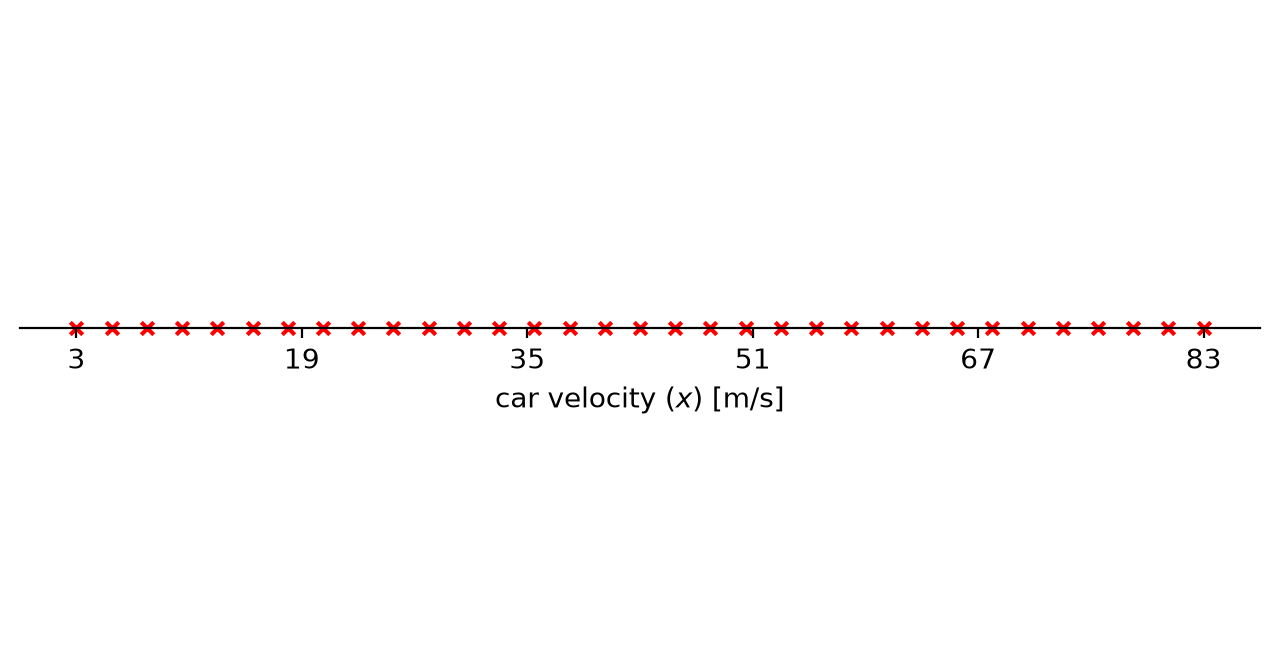

In [6]:
# @title Figure code: the car velocities (optional)
# We can create the above figure with matplotlib directly:

fig, ax = plt.subplots()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_position('zero')
ax.get_yaxis().set_visible(False)
ax.set_xlabel('car velocity ($x$) [m/s]')
ax.set_xticks(np.linspace(3.0, 83.0, 6))

ax.scatter(Data_x, np.zeros(len(Data_x)), s=20, c='red', marker='x' )
plt.show()

We combine both the **domain** and the **input data** in the `f3dasm.ExperimentData` object:

In [7]:
from f3dasm import ExperimentData

In [8]:
experiment_data = ExperimentData(input_data=Data_x, domain=domain)
experiment_data

,jobs,input
,,x
0,open,3.0
1,open,5.5
2,open,8.0
3,open,10.5
4,open,13.0
...,...,...
28,open,73.0
29,open,75.5
30,open,78.0


This object is the central piece of the data-driven process with `f3dasm`!

## Module `datageneration`: Measure the car stopping distance

<!-- <img src="../figures/reaction-braking-stopping.svg" title="Car stopping distance" width="25%" align="right"> -->

<img src="../figures/f3dasm_carstopping_datageneration.svg" title="f3dasm Car stopping distance datageneration" width="22%" align="right">

We can *create* the data from the governing equation.

${\color{red}y} = {\color{blue}z} x + 0.1 {\color{green}x}^2$

- ${\color{red}y}$ is the **output**: the car stopping distance
- ${\color{green}x}$ is the **input**: the car velocity
- ${\color{blue}z}$ is a hidden variable: an <a title="random variable">rv</a> $z$ representing the driver's reaction time (in seconds)

where $z \sim \mathcal{N}(\mu_z=1.5,\sigma_z^2=0.5^2)$

We create the function `compute_distance` with the governing equation:

In [9]:
from scipy.stats import norm # import the normal dist, as we learned before!

# Define our car stopping distance function (input is a single input sample)
def compute_distance(x): # x is an input that we define to be a float (it's not a 1D numpy array)
    z = norm.rvs(1.5, 0.5, size=1) # randomly draw 1 sample from the normal dist (z is a 1D numpy array)
    y = z*x + 0.1*x**2 # compute the stopping distance.
    # NOTE: y is a 1D numpy array due to z being a 1D numpy array, despite x being a float.
    return float(y.item()) # convert y from a 1D numpy array into a float (a scalar in Python).

<img src="../figures/car_stoppingdistance.svg" title="Car stopping distance" width="40%" align="right">

We can evaluate our input data points $x$ to retrieve the stopping distance $y$:

### METHOD 1 to generate data in f3dasm

In [10]:
from f3dasm import Block


class CarStoppingDistance(Block):
    def call(self, data: ExperimentData) -> ExperimentData:
        for _id, experiment_sample in data:

            # Extract the car velocity x from the experiment sample
            x = experiment_sample.input_data['x']

            # Evaluate the stopping distance y(x)
            distance = compute_distance(x)

            # Store the stopping distance back in the experiment sample
            experiment_sample.store(name='distance', object=distance)

            # Mark the experiment as finished
            experiment_sample.mark('finished')

        # After all experiments are finished, return the data
        return data

In [11]:
car_stopping_distance = CarStoppingDistance()
experiment_data = car_stopping_distance.call(experiment_data)
experiment_data

,jobs,input,output
,,x,distance
0,finished,3.0,5.091795
1,finished,5.5,14.664148
2,finished,8.0,14.546598
3,finished,10.5,34.158255
4,finished,13.0,37.836889
...,...,...,...
28,finished,73.0,643.105624
29,finished,75.5,682.380062
30,finished,78.0,675.198102


### METHOD 2 to generate data in f3dasm: DataGenerator class that wraps around a Block

In [12]:
from f3dasm import ExperimentSample
from f3dasm.datageneration import DataGenerator


class CarStoppingDistanceDataGenerator(DataGenerator):
    def execute(self, experiment_sample: ExperimentSample) -> ExperimentSample:
        # Extract the car velocity x from the experiment sample
        x = experiment_sample.input_data['x']

        # Evaluate the stopping distance y(x)
        distance = compute_distance(x)

        # Store the stopping distance back in the experiment sample
        experiment_sample.store(name='distance', object=distance)

        # Return the experiment sample
        return experiment_sample

In [13]:
car_stopping_distance_datagenerator = CarStoppingDistanceDataGenerator()

# Recreate the experiment data
experiment_data = ExperimentData(input_data=Data_x, domain=domain)

# Evaluate the experiment data on the DataGenerator
experiment_data = car_stopping_distance_datagenerator.call(experiment_data,
                                                           mode='sequential')

experiment_data

,jobs,input,output
,,x,distance
0,finished,3.0,6.686675
1,finished,5.5,6.743933
2,finished,8.0,15.912636
3,finished,10.5,30.193538
4,finished,13.0,20.689614
...,...,...,...
28,finished,73.0,591.069292
29,finished,75.5,695.777121
30,finished,78.0,715.584025


### METHOD 3 to generate data in f3dasm: Using the compute_distance function directly

In [14]:
from f3dasm import datagenerator


@datagenerator(output_names='distance')
def y(x):
    z = norm.rvs(1.5, 0.5, size=1)
    y = z*x + 0.1*x**2
    return float(y.item())

In [15]:
# Recreate the experiment data
experiment_data = ExperimentData(input_data=Data_x, domain=domain)

# Evaluate the experiment data on the DataGenerator
experiment_data = y.call(experiment_data, mode='sequential')

experiment_data


,jobs,input,output
,,x,distance
0,finished,3.0,5.577168
1,finished,5.5,10.800839
2,finished,8.0,23.532701
3,finished,10.5,20.170331
4,finished,13.0,32.160379
...,...,...,...
28,finished,73.0,631.225792
29,finished,75.5,695.199578
30,finished,78.0,802.345965


### Independently of the method chosen to generate data, let's plot the data we generated

We can extract the car stopping distance $y$ as a numpy array:

In [16]:
# to_numpy extracts both the input and output data as numpy arrays:
_, Data_y = experiment_data.to_numpy()

In [17]:
Data_x

array([ 3. ,  5.5,  8. , 10.5, 13. , 15.5, 18. , 20.5, 23. , 25.5, 28. ,
       30.5, 33. , 35.5, 38. , 40.5, 43. , 45.5, 48. , 50.5, 53. , 55.5,
       58. , 60.5, 63. , 65.5, 68. , 70.5, 73. , 75.5, 78. , 80.5, 83. ])

In [18]:
Data_y

array([[  5.57716779],
       [ 10.80083938],
       [ 23.53270106],
       [ 20.17033108],
       [ 32.16037867],
       [ 50.60776163],
       [ 49.41707097],
       [ 84.06887681],
       [ 84.91403083],
       [109.58688686],
       [124.28167948],
       [139.51838301],
       [154.08168306],
       [168.98570535],
       [225.51745502],
       [221.76458964],
       [221.32701844],
       [261.09027431],
       [299.60634854],
       [302.89374341],
       [383.87443306],
       [384.91158287],
       [371.74987905],
       [433.9353976 ],
       [485.38177459],
       [536.04630311],
       [595.97485336],
       [627.00720095],
       [631.22579171],
       [695.19957752],
       [802.34596522],
       [751.16967566],
       [851.12241851]])

Text(0.5, 0, 'car velocity ($x$) [m/s]')

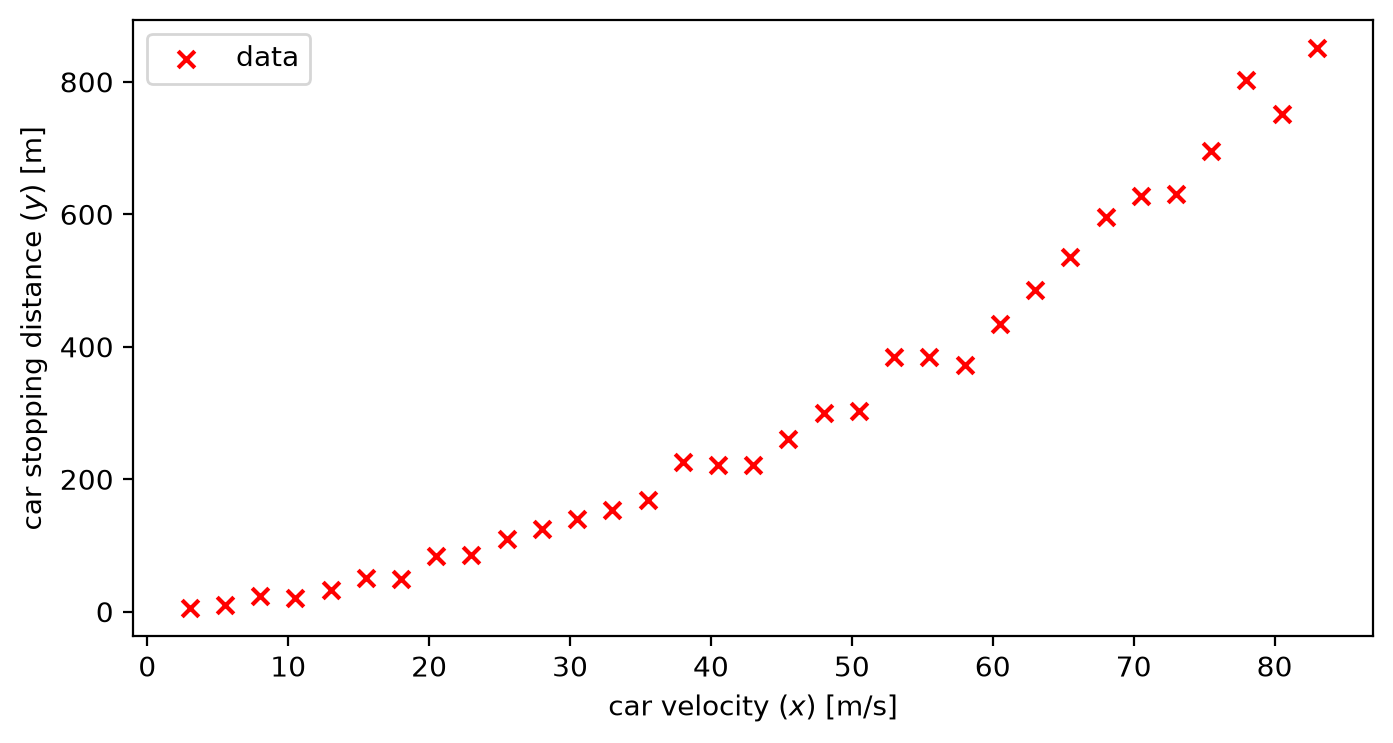

In [19]:
fig, ax = plt.subplots()
ax.scatter(Data_x, Data_y, color='r', marker='x', label='data')
ax.legend()
ax.set_ylabel('car stopping distance ($y$) [m]')
ax.set_xlabel('car velocity ($x$) [m/s]')

### Module `machine learning`: Fit a polynomial model to the data!

<img src="../figures/f3dasm_carstopping_machinelearning.svg" title="f3dasm Car stopping distance machine learning" width="22%" align="right">

In [20]:
from sklearn.preprocessing import PolynomialFeatures # For Polynomial fit
from sklearn.linear_model import LinearRegression # For Least Squares
from sklearn.pipeline import make_pipeline # to link different objects

Creating the polynomial model:

In [21]:
degree = 1
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())

Fitting the model with the data:

In [22]:
poly_model.fit(Data_x.reshape(-1, 1), Data_y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('polynomialfeatures', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,1
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",1
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
Name,Type,Value


Now, instead of using the governing equation (`compute_distance`), we can use the model to predict the car stopping distance, i.e., we will have a **new Data Generation block** that generates data **from the Linear Regression model** that we trained:

In [23]:
def compute_distance_from_model(x):
    y_pred = poly_model.predict(np.array(x).reshape(-1, 1)) # We need to reshape the input into 2D array
    return float(y_pred.item()) # convert y to a float (native Python object, instead of numpy arrays)

In [24]:
class CarStoppingDistance_from_model(Block):
    def call(self, data: ExperimentData) -> ExperimentData:
        for _id, experiment_sample in data:

            # Extract the car velocity x from the experiment sample
            x = experiment_sample.input_data['x']

            # Evaluate the stopping distance y(x)
            distance = compute_distance_from_model(x)

            # Store the stopping distance back in the experiment sample
            experiment_sample.store(name='distance', object=distance)

            # Mark the experiment as finished
            experiment_sample.mark('finished')

        # After all experiments are finished, return the data
        return data

In [25]:
experiment_data = experiment_data.mark_all('open')

In [26]:
car_stopping_distance_from_model = CarStoppingDistance_from_model()
experiment_data = car_stopping_distance_from_model.call(experiment_data)

In [27]:
experiment_data

,jobs,input,output
,,x,distance
0,finished,3.0,-104.870555
1,finished,5.5,-79.111888
2,finished,8.0,-53.353221
3,finished,10.5,-27.594555
4,finished,13.0,-1.835888
...,...,...,...
28,finished,73.0,616.372117
29,finished,75.5,642.130784
30,finished,78.0,667.889450


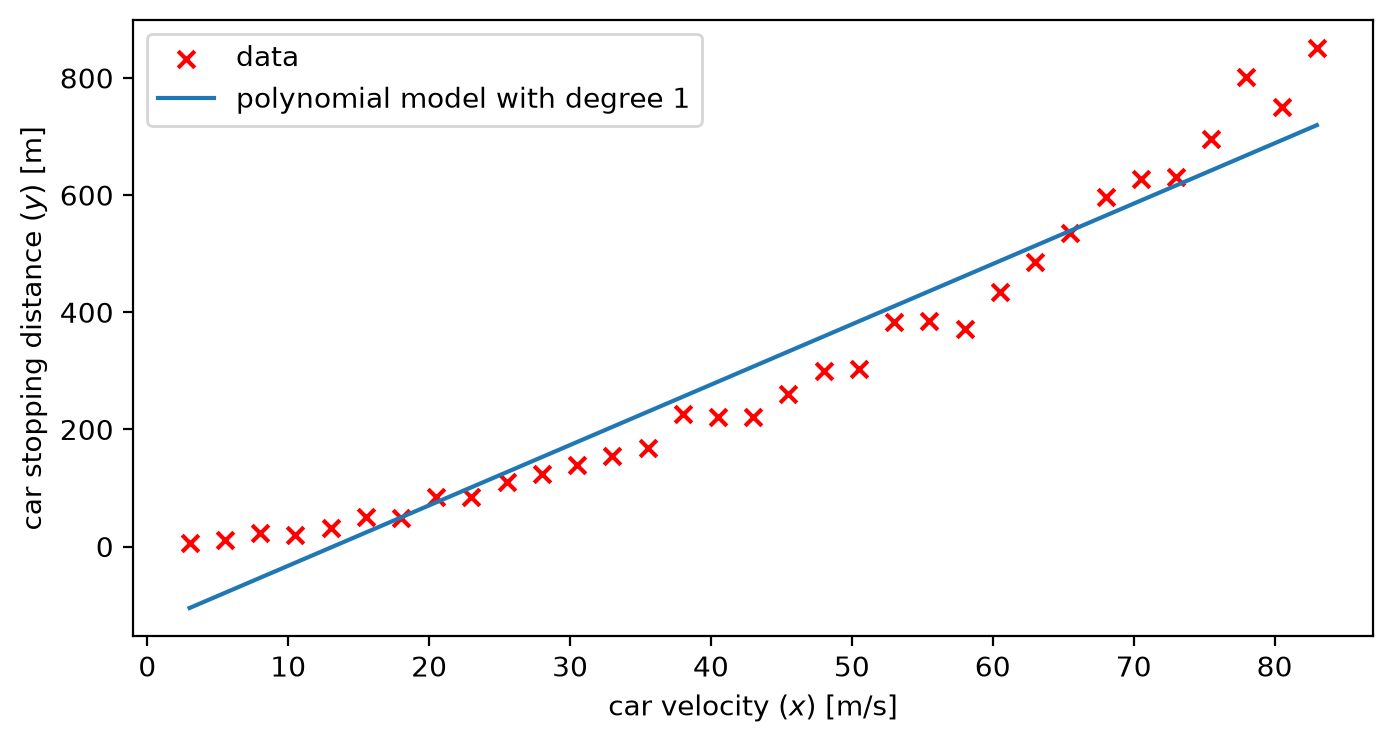

In [28]:
# Converting the ExperimentData object to numpy arrays for plotting
_, out_data = experiment_data.to_numpy()

# Plotting the data and the model prediction
fig, ax = plt.subplots()

ax.scatter(Data_x, Data_y, marker='x', color='red', label='data')
ax.plot(Data_x, out_data.ravel(), label=f'polynomial model with degree {degree}')
ax.legend()
ax.set_ylabel('car stopping distance ($y$) [m]')
ax.set_xlabel('car velocity ($x$) [m/s]')
plt.show()

## Saving the `ExperimentData`

Saving the `ExperimentData` object to your computer is easy with the `store` method:

In [29]:
experiment_data.store('./your_data')

This will create an `experiment_data` folder in the `Lecture17/your_data` directory:

```
your_data/
└── experiment_data/
     ├── domain.json
     ├── input.csv
     ├── output.csv
     └── jobs.csv    
```

Loading the `ExperimentData` from a folder is done like this:

In [30]:
ExperimentData.from_file('./your_data')

,jobs,input,output
,,x,distance
0,finished,3.0,-104.870555
1,finished,5.5,-79.111888
2,finished,8.0,-53.353221
3,finished,10.5,-27.594555
4,finished,13.0,-1.835888
...,...,...,...
28,finished,73.0,616.372117
29,finished,75.5,642.130784
30,finished,78.0,667.889450


### See you next class

Have fun!